### Congestusey

James Ruppert  
jruppert@ou.edu  
11/5/25

### Main settings

In [32]:
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.image as mpimg  # for reading images
import matplotlib.gridspec as gridspec
import matplotlib.colors as mplcolors
from matplotlib import patches
from orcestra_read_data import *
from metpy.plots import SkewT
from metpy.units import units
import metpy.calc as mpcalc
from thermo_functions import *
import cmocean
import cmcrameri.cm as cmc
import seaborn as sns

In [6]:
# Soundings
snd_asc = read_soundings(platform='RV_Meteor')
hght = snd_asc['hght']
times_asc = snd_asc['times']

#### Prep Dthdz

In [7]:
# Vertical smoothing function
def vert_smooth(invar, nz_smooth=10):
    invar_pd = pd.DataFrame(invar)
    invar_pd = (invar_pd.transpose()).rolling(window=nz_smooth, center=True, closed='both', min_periods=3).mean()
    return np.squeeze(np.array(invar_pd).transpose())

# Static stability
theta = theta_dry(snd_asc['tmpk'], snd_asc['p']) # K
# for ido in range(3):
theta = vert_smooth(theta, nz_smooth=10)
dthdz = np.gradient(theta, hght, axis=1) # K/m
dthdz = vert_smooth(dthdz, nz_smooth=10)*1e3 # --> K/km

time_2d, height_2d = np.meshgrid(times_asc, hght, indexing='ij')  # same shape (nt, nz)

df_snd = pd.DataFrame({
    'time': time_2d.flatten(),
    'hght': height_2d.flatten(),
    'tmpc': snd_asc['tmpk'].flatten()-273.15,
    'dthdz': dthdz.flatten()
})

# Remove NaNs
df_snd = df_snd.dropna()

# Identify local maxima in temperature bins
temp_bins = np.arange(-85, 40, 2)  # Define temperature bins
df_binned = (df_snd.groupby(pd.cut(df_snd['tmpc'], bins=temp_bins))
             .agg(mean_dthdz=('dthdz', 'mean'))
             .reset_index())

# Find local maxima in the mean dthdz values
from scipy.signal import find_peaks
dthdz_peaks, _ = find_peaks(df_binned['mean_dthdz'])

/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_34923/943576747.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = (df_snd.groupby(pd.cut(df_snd['tmpc'], bins=temp_bins))


### Main multi-panel plot

In [50]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 18}

rc('font', **font)

# Scaling for text annotations
fontscale = 0.8

# sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})

#### Prep SkewT

In [9]:
import datetime as dt

# times_asc[164]
time_select = 164

time_date = times_asc[time_select]
t_dt = time_date.astype('datetime64[ms]').astype(dt.datetime)
# time_date_str = t_dt.strftime("%d %b %Y, %H:%M UTC")
time_date_str = t_dt.strftime("%H:%M UTC")

p = snd_asc['p'][time_select,:].data*1e-2 * units.hPa
T = (snd_asc['tmpk'][time_select,:].data - 273.15)* units.degC
mr = snd_asc['mr'][time_select,:].data * 1e3 * units('g/kg')
sh = mpcalc.specific_humidity_from_mixing_ratio(mr) * units.dimensionless#units('g/kg')
Td = mpcalc.dewpoint_from_specific_humidity(p, sh)# * units.degC
u = snd_asc['u'][time_select,:].data * units('m/s').to(units('knots'))
v = snd_asc['v'][time_select,:].data * units('m/s').to(units('knots'))

#### Subplot driver functions

In [83]:
# SkewT plot

def add_skewt(fig, subplot, p, T, Td, u, v, time_date_str):

    rotation = 40
    skew = SkewT(fig, rotation=rotation, subplot=subplot)

    # Plot wind barbs
    # thin the wind data for better visibility
    # skew.plot_barbs(p, wdir, wspd)
    nskip = 50
    top = np.where(p > 100*units.hPa)[0][-1]
    skew.plot_barbs(p[:top:nskip], u[:top:nskip], v[:top:nskip])

    # Add grid lines, labels, and legend
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-25, 34)
    skew.ax.set_xlabel('Temperature [°C]',fontsize=fontscale*font['size'])
    skew.ax.set_ylabel('Pressure [hPa]',fontsize=fontscale*font['size'])
    skew.ax.legend(loc='best')
    skew.ax.set_title(time_date_str,fontsize=fontscale*font['size'])
    skew.ax.tick_params(labelsize=fontscale*font['size']*0.9)

    # Add adiabats, mixing ratio lines
    lw=1.6
    alpha=0.2
    ls='--'
    skew.plot_dry_adiabats(
        t0=(np.array([-90,45])+273.15)*units.K,
        linestyle=ls, linewidth=lw, alpha=alpha, colors='black')
    skew.plot_moist_adiabats(
        t0=(np.array([-90,25])+273.15)*units.K,
        linestyle=ls, linewidth=lw, alpha=alpha, colors='black')
    skew.plot_mixing_lines(
        np.array([0,13])*units('g/kg'),pressure=np.arange(1020, 680, -2)*units.hPa,
        linestyle=ls, colors='black', linewidth=lw, alpha=alpha)

    # Remove stuff
    skew.ax.grid(visible=False, axis='y')
    skew.ax.grid(visible=True, axis='x')
    skew.ax.legend_.remove()

    # Only show select isotherms
    skew.ax.grid(visible=False, axis='x')
    # skew.ax.xaxis.get_major_ticks()[5].set_visible(True)
    p_vals = np.linspace(1000, 100, 50)  # hPa
    for it0 in np.arange(-120,120,20):
        T_iso = np.full_like(p_vals, it0) * units.degC
        skew.plot(p_vals * units.hPa, T_iso, color='black', linestyle='-', linewidth=lw, alpha=alpha)
    # Add additional isotherms
    for it0 in [-5,13]:
        T_iso = np.full_like(p_vals, it0) * units.degC
        skew.plot(p_vals * units.hPa, T_iso, color='black', linestyle='--', linewidth=lw, alpha=alpha)
        plab = 340 if it0 < 0 else 600
        skew.ax.text(
            ((it0-2.5) * units.degC).m, ((plab-45) * units.hPa).m,
            f'{it0}°C', rotation=50, rotation_mode='anchor',
            ha='left', va='center',
            fontsize=fontscale*font['size'], color='k', alpha=0.7
        )

    # Overlay height line at inversion
    pr = np.array(p)
    izloc = np.where(pr <= 490)[0]
    plev = p[izloc[0]]
    hght_line = hght[izloc[0]]/1e3
    skew.ax.axhline(y=plev, color='black', linestyle='--', linewidth=lw, alpha=alpha)
    skew.ax.text(
        (-34 * units.degC).m, plev.m+30,
        f'{hght_line:.1f} km', #rotation=50, rotation_mode='anchor',
        ha='left', va='center',
        fontsize=fontscale*font['size'], color='k', alpha=0.7
    )

    # Plot temperature and dewpoint
    skew.plot(p, T, 'r', label='Temperature', linewidth=1.2)
    skew.plot(p, Td, 'g', label='Dewpoint', linewidth=1.2)
    
    return None

In [96]:
# Static stability CFAD

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_cfad(ax_cfad, df_snd, dthdz_peaks, temp_bins):

    cfad = ax_cfad.hexbin(df_snd['dthdz'], df_snd['tmpc'],
                gridsize=[35,35],
                extent=(-2,12,-85,35),
                cmap=cmocean.cm.rain,
                vmin=100, vmax=1200)

    # Find local maxima in the mean dthdz values
    for peak in dthdz_peaks[[3,4]]:
        temp_value = temp_bins[peak]
        ax_cfad.axhline(y=temp_value, color='black', linestyle='--', linewidth=1)
        # Plot T value
        ax_cfad.text(8, temp_value-2, f'{temp_value}°C', color='black', fontsize=fontscale*font['size'])

    ax_cfad.set_xlabel(r'$d\theta/dz$ [K/km]',fontsize=fontscale*font['size'])
    ax_cfad.invert_yaxis()
    ax_cfad.set_xlim(-2, 10)
    ax_cfad.set_ylabel('Temperature (°C)', fontsize=fontscale*font['size'])
    ax_cfad.grid(True, alpha=0.7)
    ax_cfad.set_title('(e) All Meteor Soundings', fontsize=fontscale*font['size'])
    ax_cfad.tick_params(labelsize=fontscale*font['size']*0.9)

    # cb = plt.colorbar(cfad, ax=ax_cfad, extend='max', #label='Counts',
    #                   shrink=0.6, anchor=(-0.2,0.5))

    # Create an inset Axes for the colorbar inside the CFAD panel
    cb_ax = inset_axes(
        ax_cfad,
        width="3%",     # width of colorbar relative to CFAD panel
        height="50%",   # height of colorbar relative to CFAD panel
        loc='upper right',
        bbox_to_anchor=(-0.25, -0.05, 1, 1),  # small shift inward if desired
        bbox_transform=ax_cfad.transAxes,
        borderpad=0
    )
    cb = plt.colorbar(cfad, cax=cb_ax, orientation='vertical', extend='max')# label='Counts')
    cb.ax.tick_params(labelsize=fontscale*font['size']*0.9)
    cb.ax.set_ylabel('Counts', fontsize=fontscale*font['size']*0.9)
    
    return None

In [39]:
# Rotate a colormap

def rotate_cmap(cmap, shift=0.5):
    """
    cmap: input colormap
    shift: fraction of the colormap to rotate
    """
    n = cmap.N
    colors = cmap(np.arange(n))   # shape (n, 4)
    k = int(n * shift)                 # rotate by k color steps
    colors_rot = np.vstack([colors[k:], colors[:k]])
    cmap = mplcolors.ListedColormap(colors_rot)
    return cmap

In [69]:
# Radar helper functions

#piccolo_file = "data/PICCOLO_level4_volume_3D_09-05-24T18-19UTC_dbzrain.nc"
piccolo_file = "ipfs://bafybeifryiuhi64d6vjod6mkrfaa3rxtjrfjlv7lmvjznagzpb3q6bfyea"
subset_scale = 0.55

# Subset to region
def subset_region(dataarray, scale=0.5):
    """
    scale: fraction of domain to keep (0–1)
    """
    ny = dataarray.sizes['Y']   # or 'y'
    nx = dataarray.sizes['X']   # or 'x'
    ny_sub = int(1 * ny)
    nx_sub = int(scale * nx)
    iy0 = (ny - ny_sub) // 2
    ix0 = (nx - nx_sub) // 2
    dataarray_sub = dataarray.isel(
        Y=slice(iy0, iy0 + ny_sub),
        X=slice(ix0, ix0 + nx_sub),
    )
    return dataarray_sub

def get_reflectivity():
    seapol = xr.open_dataset(piccolo_file,engine='zarr')
    # Set map time
    time_map = np.datetime64('2024-09-05T19:00')
    itime = np.abs(pd.to_datetime(seapol.time) - time_map).argmin()
    map_dbz = seapol.DBZ[itime,:,:,:]
    map_dbz = subset_region(map_dbz, scale=subset_scale)
    return map_dbz

def get_rainrate_3d():
    seapol = xr.open_dataset(piccolo_file,engine='zarr')
    # Set map time
    time_map = np.datetime64('2024-09-05T19:00')
    itime = np.abs(pd.to_datetime(seapol.time) - time_map).argmin()
    rainrate = seapol.RAINRATE[itime,0,:,:]
    rainrate = subset_region(rainrate, scale=subset_scale)
    return rainrate

def get_rainrate_2d():
    #piccolo_file = "data/PICCOLO_level4_rainrate_2D_09-05-24T18-19UTC.nc"
    piccolo_file = "ipfs://bafybeigv34pwsk3t5wlmatncnavfsfie5zyd6j36eyv57qsh6f7usn5kg4"
    seapol = xr.open_dataset(piccolo_file,engine='zarr')
    # Set map time
    time_map = np.datetime64('2024-09-05T19:00')
    itime = np.abs(pd.to_datetime(seapol.time) - time_map).argmin()
    rainrate = seapol.RAINRATE[itime,:,:]

    # Get dimension names (e.g., ('y', 'x'))
    ydim, xdim = rainrate.dims
    ny = rainrate.sizes[ydim]
    nx = rainrate.sizes[xdim]
    # Target sizes: half in each direction
    ny_new = ny // 2
    nx_new = nx // 2
    # Centers in index space
    y_center = ny // 2
    x_center = nx // 2
    # Start/stop indices for cropping around center
    y_start = y_center - ny_new // 2
    y_stop  = y_start + ny_new
    x_start = x_center - nx_new // 2
    x_stop  = x_start + nx_new
    # Crop around the center
    rainrate = rainrate.isel({ydim: slice(y_start, y_stop),
                              xdim: slice(x_start, x_stop)})

    rainrate = subset_region(rainrate, scale=subset_scale)
    return rainrate

def get_echo_top_height():
    map_dbz = get_reflectivity()
    # Find maximum height where the reflectivity is above a threshold
    dbz_threshold = 10
    z = map_dbz['Z']
    z_masked = z.where(map_dbz >= dbz_threshold) # keeps z only where condition is met
    echo_top_height = z_masked.max(dim='Z')    # returns NaN if never met
    return map_dbz, echo_top_height

# Add colorbar as inset
def add_radar_cbar(ax_rad, cax, label='Echo Top Height (km)'):
    # Create an inset Axes for the colorbar inside the CFAD panel
    cb_ax = inset_axes(
        ax_rad,
        width="4.5%",     # width of colorbar relative to CFAD panel
        height="45%",   # height of colorbar relative to CFAD panel
        loc='upper right',
        # bbox_to_anchor=(-0.25, -0.03, 1, 1),  # small shift inward if desired
        bbox_to_anchor=(-0.05, -0.03, 1, 1),  # small shift inward if desired
        bbox_transform=ax_rad.transAxes,
        borderpad=0
    )
    cbar = plt.colorbar(cax, cax=cb_ax, orientation='vertical', extend='max')# label='Counts')
    cbar.ax.tick_params(labelsize=fontscale*font['size']*0.9)
    cbar.ax.set_ylabel(label, fontsize=fontscale*font['size']*0.9)#, fontsize=18)
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    return None

def plot_radius_circles(ax_circ, radvar, add_labels=True):
    radius_plot = [18, 50]#, 120]
    ny, nx = radvar.shape[-2], radvar.shape[-1]
    iy = ny // 2
    ix = nx // 2
    lon0 = float(radvar.longitude[iy, ix])
    lat0 = float(radvar.latitude[iy, ix])
    km_per_deg_lat = 111.32
    km_per_deg_lon = km_per_deg_lat * np.cos(np.deg2rad(lat0))  # scale with latitude
    for radius in radius_plot:
        # Draw the circle (same as before)
        ax_circ.add_patch(
            plt.Circle((lon0, lat0),radius / km_per_deg_lat,
                       color='gray',alpha=0.7,fill=False,
                       linestyle='--',linewidth=0.5,)
        )
        if add_labels:
            # Distance from center where label should go (in km)
            label_offset = 2 if radius == 18 else 3  # keep your logic
            label_dist = radius + label_offset       # km from center along the diagonal
            # Component along x and y for a 45° line: dx = dy = label_dist / sqrt(2)
            d_km = label_dist / np.sqrt(2)
            # Convert km to degrees
            dlat = -d_km / km_per_deg_lat          # negative => go "down" (south)
            dlon =  d_km / km_per_deg_lon          # positive => go "right" (east)
            lon_label = lon0 + dlon
            lat_label = lat0 + dlat
            ax_circ.text(lon_label,lat_label,
                f'{radius} km',fontsize=fontscale * font['size'],
                color='black',alpha=0.7,
                va='center',ha='left',
            )
    return None

In [127]:
# SEAPOL echo top height map

def seapol_plot_echo_top_height(ax_echotop):

    map_dbz, echo_top_height = get_echo_top_height()

    # z_vals = np.arange(0, 11, 1)
    z_vals = np.unique(echo_top_height)/1e3
    z_vals = z_vals[np.isfinite(z_vals)]
    bins = np.arange(z_vals.min(), z_vals.max()+1, 1) # 1 km bins
    n = len(bins) - 1

    # Create N discrete colors from a colormap
    #cmap_name='vanimo'
    cmap_name = cmc.vanimo
    #cmap_name = 'viridis'
    #cmap_name='managua_r'
    cmap = plt.get_cmap(cmap_name, n)
    cmap = rotate_cmap(cmap, shift=0.4)
    #norm = mplcolors.BoundaryNorm(bins, n)
    norm = mplcolors.BoundaryNorm(bins, cmap.N, clip=True)

    cax = ax_echotop.pcolormesh(map_dbz.longitude, map_dbz.latitude, echo_top_height/1e3,
                        cmap=cmap, norm=norm)
    ax_echotop.set_aspect('equal',adjustable='box')

    # cbar = fig.colorbar(cax, ax=ax_echotop, orientation='vertical', pad=0.02, shrink=0.6)
    add_radar_cbar(ax_echotop, cax, label='km')

    # string_format = '%Y-%m-%d %H:%M'
    string_format = '%H:%M'
    dt_str = pd.to_datetime(map_dbz.time.values).strftime(string_format)
    # ax_echotop.set_title(dt_str + ' UTC')#,fontsize=18)
    ax_echotop.set_title('(d) Echo-top Height',fontsize=fontscale*font['size'])#,fontsize=18)
    # ax_echotop.tick_params(axis='both', labelsize=18)
    ax_echotop.set_xlabel('Longitude', fontsize=fontscale*font['size'])
    # ax_echotop.set_ylabel('Latitude')#, fontsize=18)
    # Remove latitude ticks
    ax_echotop.set_yticklabels([])
    # Specify number of ticks
    ax_echotop.xaxis.set_major_locator(plt.MaxNLocator(nbins=3))
    ax_echotop.tick_params(labelsize=fontscale*font['size']*0.9)

    # Add grid lines, radius circles
    # ax_echotop.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    # ax_echotop.scatter(map_dbz.longitude[120,120],map_dbz.latitude[120,120],s=60,color='black')

    # Plot direction arrow from radar
    # direction_deg = 190 # 0 = North, 90 = East, 180 = South, 270 = West
    # length_km = 15       # arrow length in kilometers
    # theta = np.deg2rad(direction_deg)
    # # Convert km to degrees (approx): 1 deg ~ 111.32 km
    # dx = (length_km * np.sin(theta)) / 111.32  # longitude delta
    # dy = (length_km * np.cos(theta)) / 111.32  # latitude delta
    # rad_lon = float(map_dbz.longitude[120,120])
    # rad_lat = float(map_dbz.latitude[120,120])
    # ax_echotop.annotate(
    #     '', xy=(rad_lon + dx, rad_lat + dy), xytext=(rad_lon, rad_lat),
    #     arrowprops=dict(arrowstyle='->', color='black', linewidth=3, alpha=0.6))

    plot_radius_circles(ax_echotop, map_dbz, add_labels=False)

    return None

In [129]:
# SEAPOL reflectivity map

def seapol_plot_reflectivity(ax_refl):

    map_dbz = get_reflectivity()

    # Create N discrete colors from a colormap
    bins = np.arange(5,55,5)
    # bins = np.arange(-10,65,5)
    n = len(bins) - 1
    # cmap_name='vanimo_r'
    #cmap_name='managua'
    cmap_name = cmc.managua 
    cmap = plt.get_cmap(cmap_name, n)
    # cmap = rotate_cmap(cmap, shift=0.4)
    norm = mplcolors.BoundaryNorm(bins, n)

    # Read the colormap from a .txt file
    def load_chase_colormap():
        # Load RGB values from the file
        file_path = 'chase-spectral-rgb.txt'
        rgb_values = np.loadtxt(file_path)
        binsize = 5
        bins = np.arange(-10,60+binsize,binsize)
        cmap = mplcolors.ListedColormap(rgb_values)
        norm = mplcolors.BoundaryNorm(bins, cmap.N, clip=True)
        return cmap, norm
    cmap, norm = load_chase_colormap()

    # Compute the field once
    dbz_max = map_dbz.max(dim='Z')
    # Mask out values below the minimum bin edge
    dbz_max_masked = dbz_max.where(dbz_max >= bins[0])

    cax = ax_refl.pcolormesh(map_dbz.longitude, map_dbz.latitude, dbz_max_masked,
                        cmap=cmap, norm=norm)
    ax_refl.set_aspect('equal',adjustable='box')

    add_radar_cbar(ax_refl, cax, label='dBZ')

    # string_format = '%Y-%m-%d %H:%M'
    string_format = '%H:%M'
    dt_str = pd.to_datetime(map_dbz.time.values).strftime(string_format)
    # ax_refl.set_title(dt_str + ' UTC')#,fontsize=18)
    ax_refl.text(0.02, 0.98, dt_str + ' UTC',
        transform=ax_refl.transAxes,
        fontsize=fontscale * font['size'],
        ha='left', va='top')
    ax_refl.set_title('(c) Max Reflectivity',fontsize=fontscale*font['size'])#,fontsize=18)
    # ax_refl.tick_params(axis='both', labelsize=18)
    ax_refl.set_xlabel('Longitude', fontsize=fontscale*font['size'])
    ax_refl.set_ylabel('Latitude', fontsize=fontscale*font['size'])
    ax_refl.xaxis.set_major_locator(plt.MaxNLocator(nbins=3))
    ax_refl.tick_params(labelsize=fontscale*font['size']*0.9)

    plot_radius_circles(ax_refl, map_dbz)

    return None

#### Create plot

/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_34923/780672531.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  skew.ax.legend(loc='best')
/opt/anaconda3/envs/awing/lib/python3.12/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/opt/anaconda3/envs/awing/lib/python3.12/site-packages/metpy/calc/thermo.py:1404: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
/var/folders/ym/zbw7d2hd013cdrqzhhl0z7580000gn/T/ipykernel_34923/2993500684.py:35: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pc

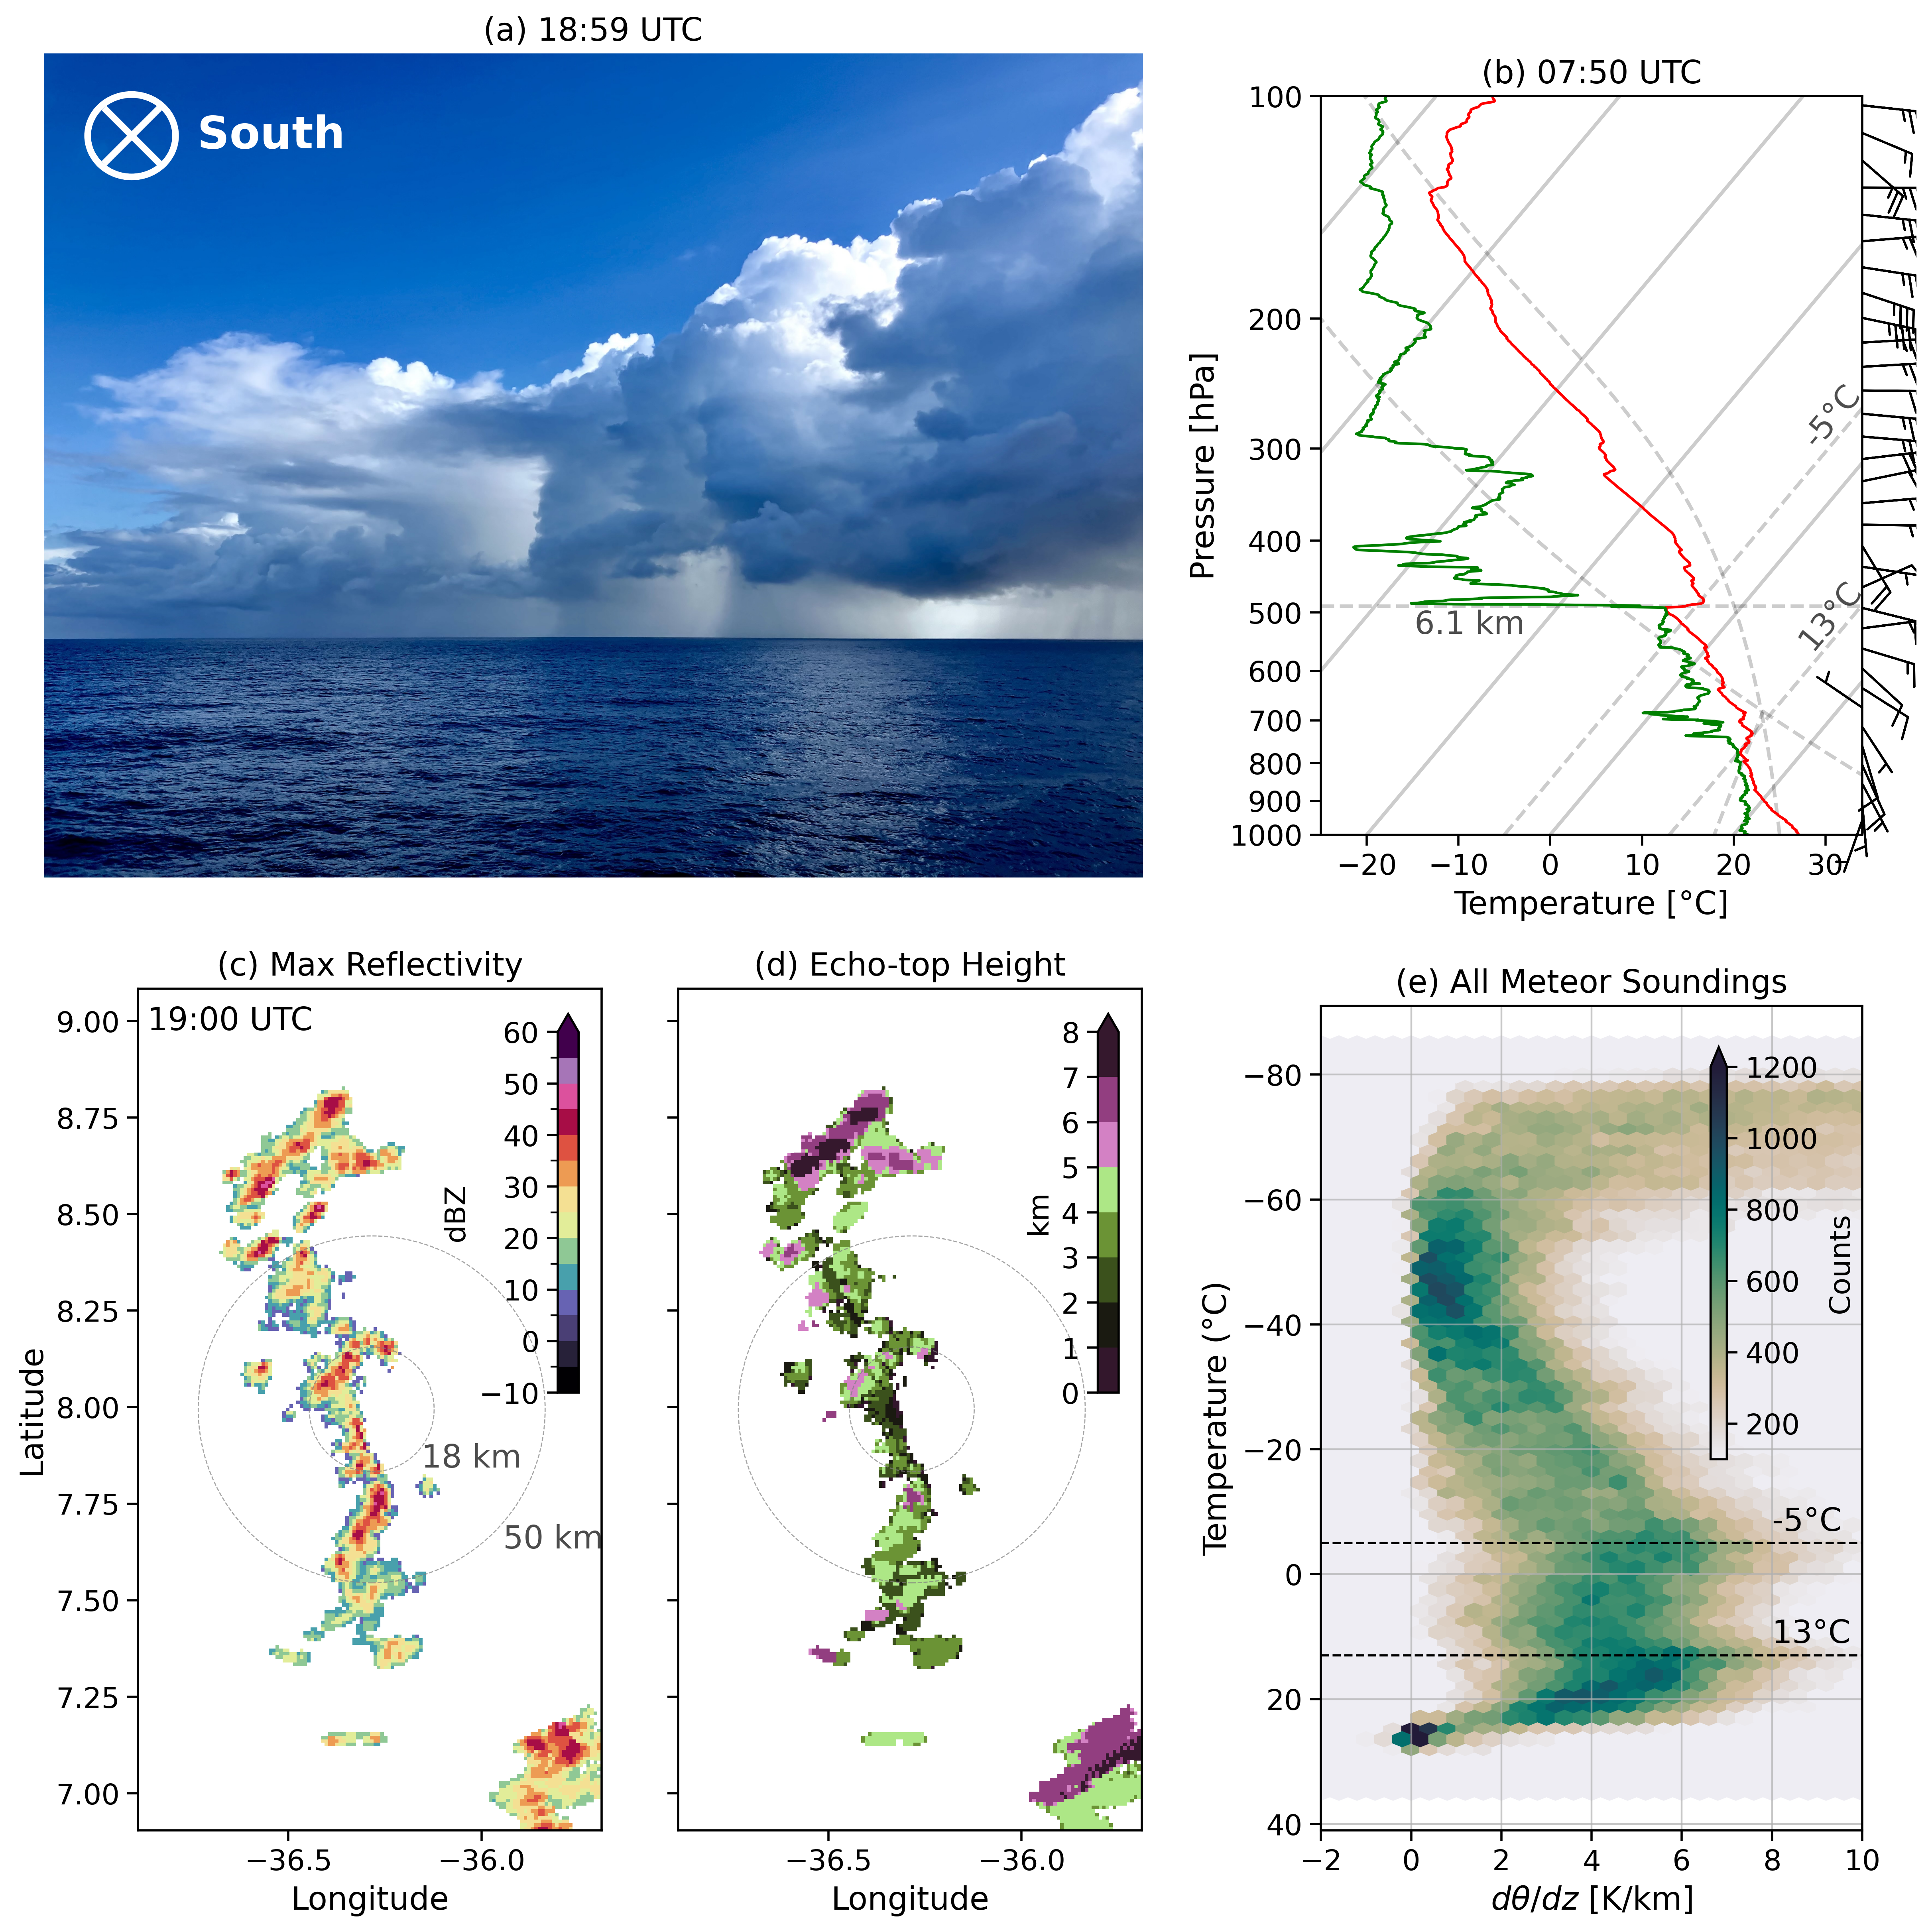

In [130]:
# --- Create multi-panel figure ---
fig = plt.figure(figsize=(12, 12), dpi=400, constrained_layout=True)
# gs = gridspec.GridSpec(2, 2, figure=fig)
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.6, 0.75],  # slightly widen first column
    height_ratios=[1.0, 1.0],
    hspace=0.05   # vertical spacing between rows
)

################################################################################
# Add Congestus photo to figure

img = mpimg.imread("congestus_photo_5Sept24.jpg")  # your image file
ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(img)
ax_img.axis("off")  # turn off axes for image display
title_str = '(a) 18:59 UTC'
ax_img.set_title(title_str,fontsize=fontscale*font['size'])#, fontsize=14)

def add_circle_x(ax):
    normalized_x, normalized_y = 0.08, 0.9
    marker_size = 630
    circle_radius_normalized = 0.04
    circle = patches.Ellipse((normalized_x, normalized_y), 
                    width=circle_radius_normalized * 2,
                    height=circle_radius_normalized * 2.5,
                    transform=ax.transAxes, 
                    edgecolor='white', 
                    facecolor='none', 
                    linewidth=3)
    ax.add_patch(circle)
    ax.scatter(normalized_x, normalized_y,
               s=marker_size, c='white', marker='x', linewidths=3,
               transform=ax.transAxes, clip_on=False)
    ax.text(normalized_x+0.06, normalized_y, 'South', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes,
            fontsize=fontscale*font['size']*1.4, color='white', weight='bold')
    return None
add_circle_x(ax_img)

################################################################################
# SkewT plot

gs_skewt = gs[0, 1]
add_skewt(fig, gs_skewt, p, T, Td, u, v, "(b) " + time_date_str)

################################################################################
# Composite reflectivity

# ax_echotop = fig.add_subplot(gs[1, 0])
parent = gs[1, 0]
sub_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2,                     # nrows, ncols
    subplot_spec=parent,   # subdividing this slot
    wspace=0, hspace=0
)
ax_sub1 = fig.add_subplot(sub_gs[0, 0])
seapol_plot_reflectivity(ax_sub1)
# seapol_plot_rainrate(ax_sub1)

ax_sub2 = fig.add_subplot(sub_gs[0, 1])
seapol_plot_echo_top_height(ax_sub2)

# ax_sub_combined = fig.add_subplot(gs[1, 0])
# ax_sub_combined.set_title(f'SEAPOL, {time_tag}')#, fontsize=fontscale*font['size']*1.2)
# ax_sub_combined.axis("off")

################################################################################
# Static stability CFAD

ax_cfad = fig.add_subplot(gs[1, 1])
add_cfad(ax_cfad, df_snd, dthdz_peaks, temp_bins)

# Show the plot
plt.savefig('./figures/Fig_congestus.png', dpi=400, bbox_inches='tight')
plt.show()
plt.close()